In [1]:
# Bibliotecas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, f1_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold

semidirect = 0; direct = 1; indirect = 2
Target = sample age

In [2]:
df = pd.read_excel('dataset_ultrasound_durrani.xlsx')
df = df.drop(columns='Fiber_Content')
df

,Path_Length,Travel_time_54,UPV_54,Travel_time_250,UPV_250,Configuration,Target
0,0.533,109.3,4880.15,111.3,4788.859,0,1
1,0.445,91.1,4879.25,93.1,4779.807,0,1
2,0.342,68.6,4980.03,72.3,4730.290,0,1
3,0.229,44.2,5171.95,47.2,4851.695,0,1
4,0.499,102.7,4857.41,105.2,4743.346,0,1
...,...,...,...,...,...,...,...
560,0.076,12.2,6245.90,17.3,4393.060,2,28
561,0.152,30.7,4964.17,33.2,4578.310,2,28
562,0.229,46.9,4874.20,52.1,4395.390,2,28
563,0.305,62.2,4900.32,68.4,4459.060,2,28


In [3]:
categorical = pd.get_dummies(df['Configuration'], prefix='Configuration')
df = df.drop(columns='Configuration')
df = pd.concat((df, categorical), axis=1)
df

,Path_Length,Travel_time_54,UPV_54,Travel_time_250,UPV_250,Target,Configuration_0,Configuration_1,Configuration_2
0,0.533,109.3,4880.15,111.3,4788.859,1,True,False,False
1,0.445,91.1,4879.25,93.1,4779.807,1,True,False,False
2,0.342,68.6,4980.03,72.3,4730.290,1,True,False,False
3,0.229,44.2,5171.95,47.2,4851.695,1,True,False,False
4,0.499,102.7,4857.41,105.2,4743.346,1,True,False,False
...,...,...,...,...,...,...,...,...,...
560,0.076,12.2,6245.90,17.3,4393.060,28,False,False,True
561,0.152,30.7,4964.17,33.2,4578.310,28,False,False,True
562,0.229,46.9,4874.20,52.1,4395.390,28,False,False,True
563,0.305,62.2,4900.32,68.4,4459.060,28,False,False,True


<Axes: >

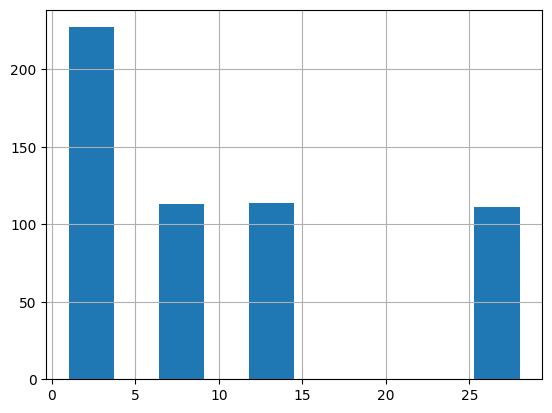

In [4]:
df.Target.hist()

In [5]:
print(df.columns)

Index(['Path_Length', 'Travel_time_54', 'UPV_54', 'Travel_time_250', 'UPV_250',
       'Target', 'Configuration_0', 'Configuration_1', 'Configuration_2'],
      dtype='object')


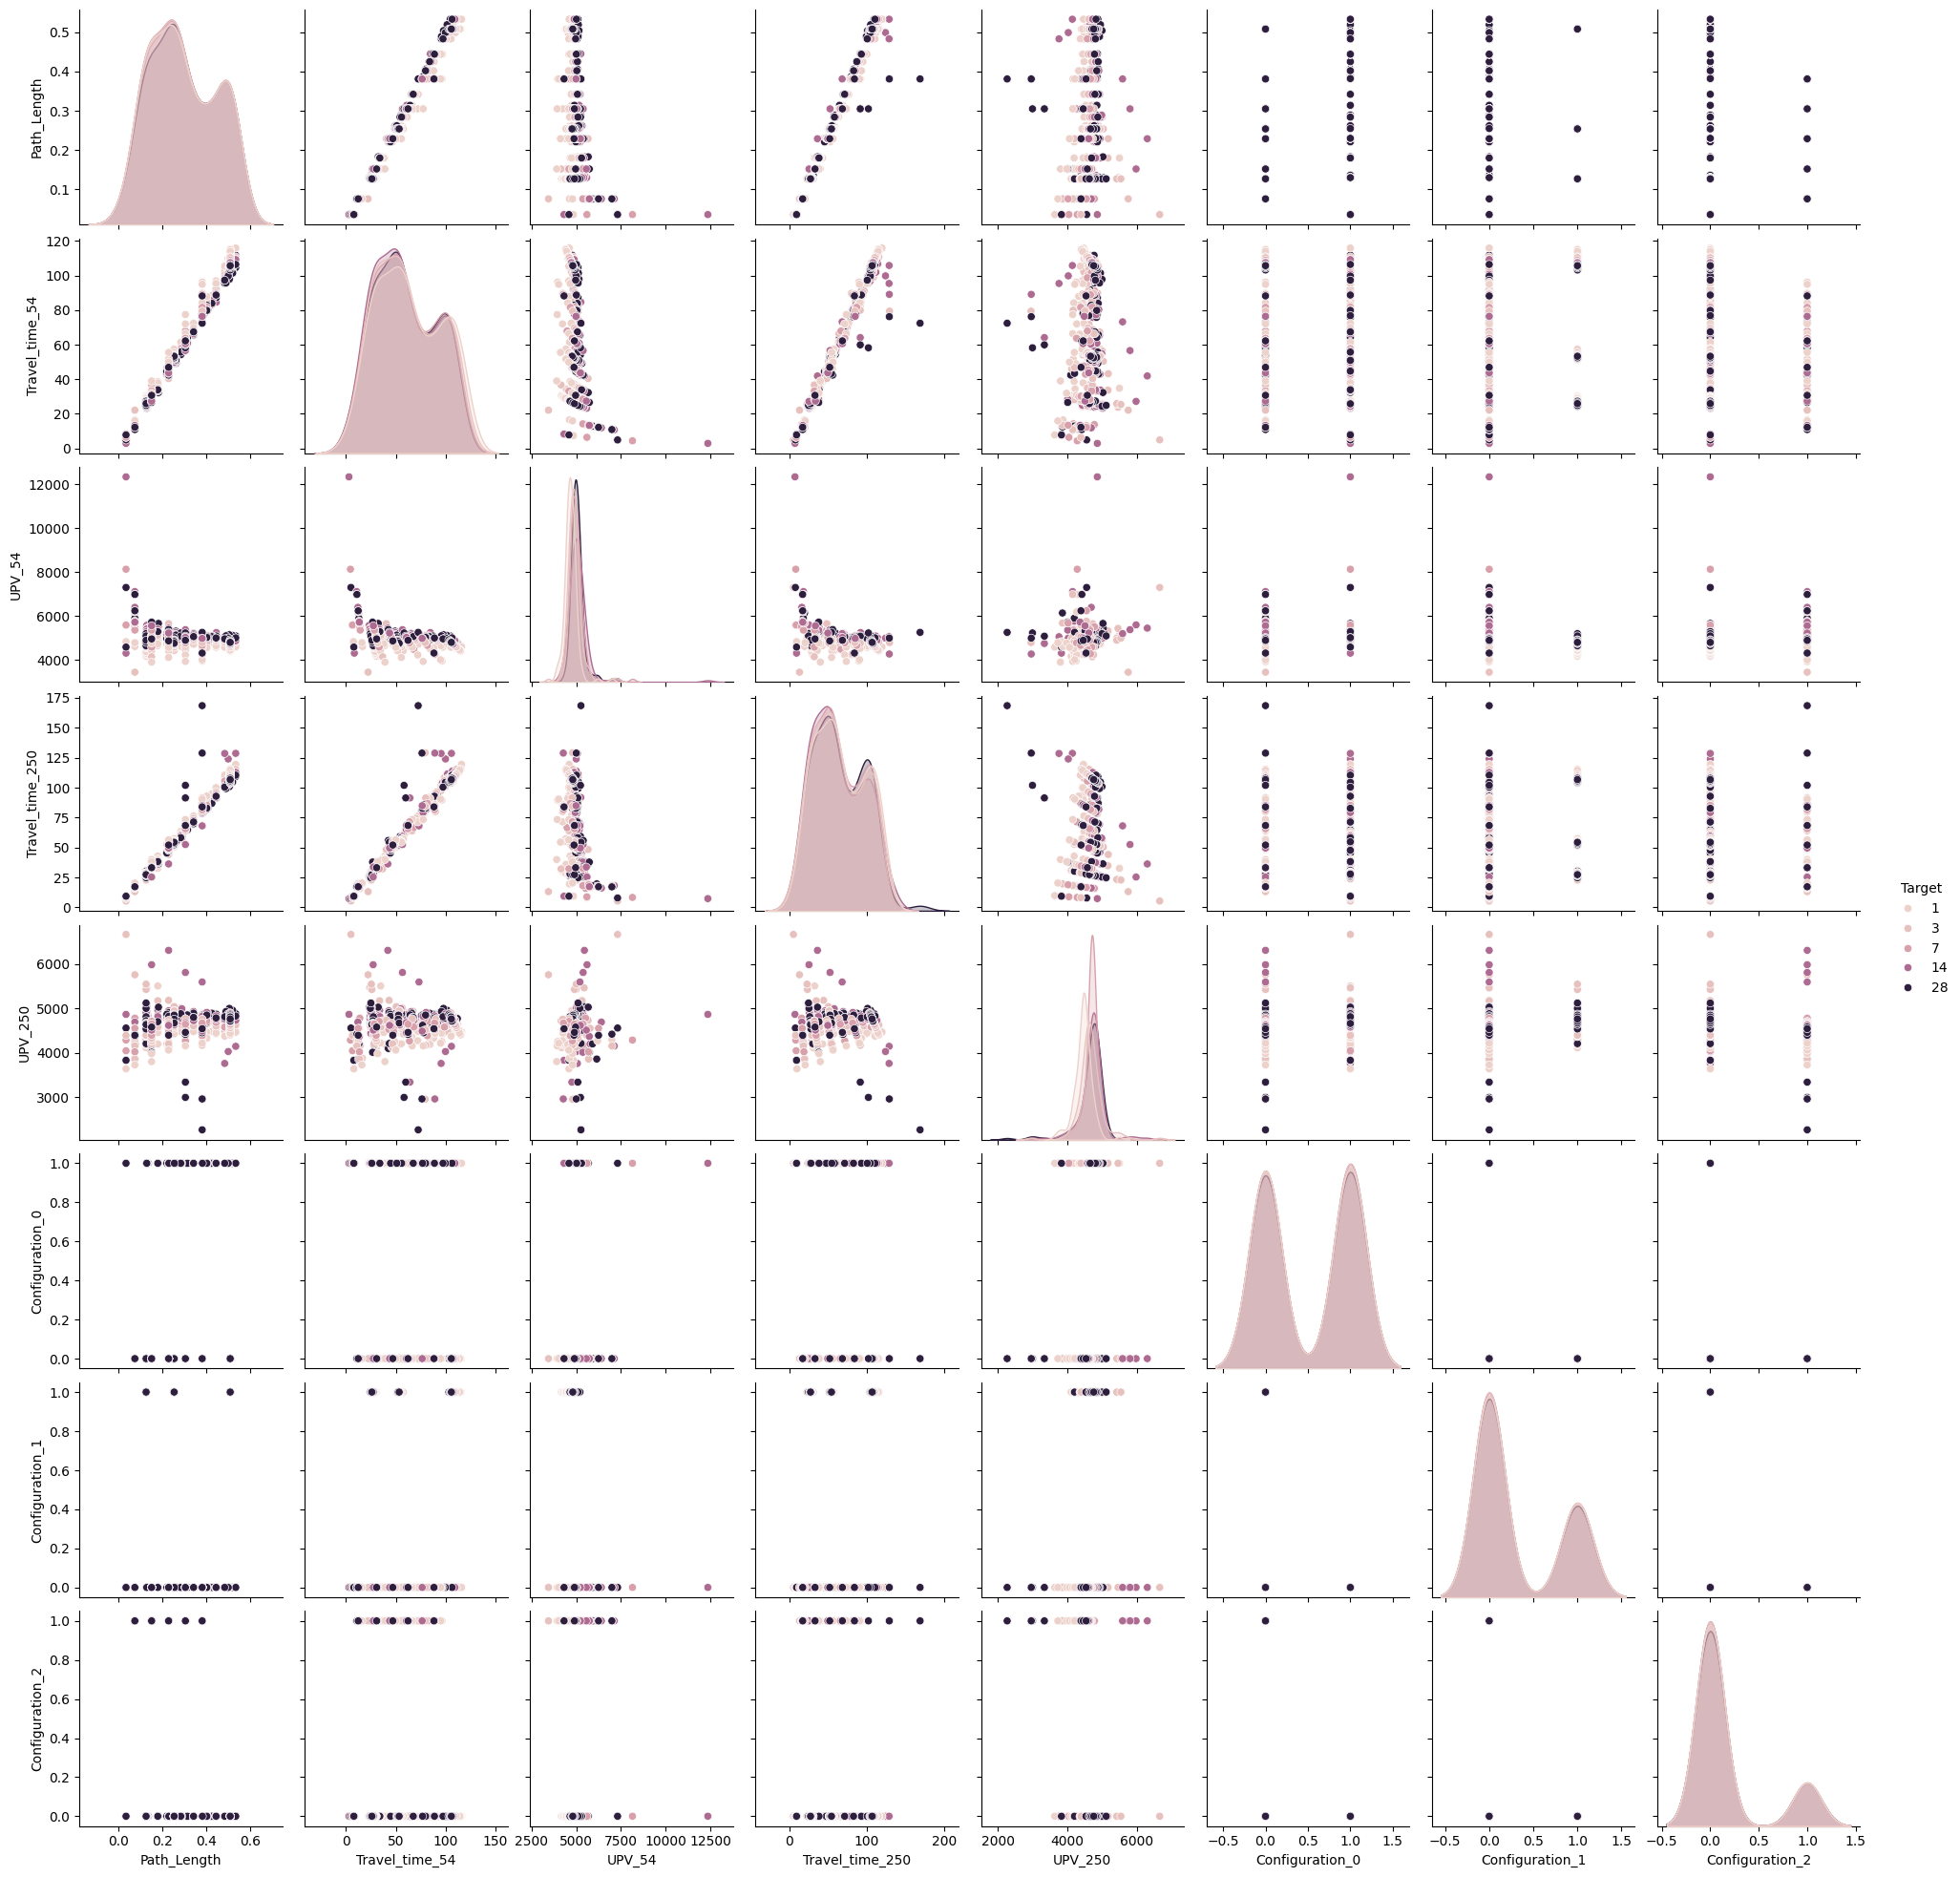

In [6]:
sns.pairplot(df, hue='Target')
plt.show()

In [7]:
#df = df.dropna(subset=['Target'])
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

In [8]:
df_test

,Path_Length,Travel_time_54,UPV_54,Travel_time_250,UPV_250,Target,Configuration_0,Configuration_1,Configuration_2
538,0.305,62.2,4900.32,69.1,4413.890,28,False,False,True
523,0.305,63.7,4784.93,71.1,4289.730,3,False,False,True
234,0.180,34.9,5145.51,39.3,4580.153,3,True,False,False
524,0.381,79.9,4768.46,91.4,4168.490,3,False,False,True
486,0.152,28.2,5404.26,36.4,4175.820,28,False,False,True
...,...,...,...,...,...,...,...,...,...
421,0.127,28.9,4394.46,28.4,4471.830,1,False,True,False
381,0.508,114.9,4421.24,114.9,4421.240,1,False,True,False
519,0.381,84.2,4524.94,91.0,4186.810,1,False,False,True
403,0.127,26.3,4828.90,27.4,4635.040,14,False,True,False


In [9]:
target = 'Target'
attributes = list(df.columns[(df.columns != target)])

In [10]:
#Padronizando dados:

min_max_scaler = preprocessing.MinMaxScaler()
min_max_scaler.fit(df_train[attributes])

# transformar os dados para a nova escala (treino e teste)
df_train_norm = min_max_scaler.transform(df_train[attributes])
df_test_norm = min_max_scaler.transform(df_test[attributes])

In [11]:
models_k = {}
 
for k in [1, 3, 5]:
    # preparando o knn com voto ponderado
    knn_norm = KNeighborsClassifier(n_neighbors=k,weights='distance',metric='euclidean')

    # conjunto de treino
    X_train = df_train_norm
    y_train = df_train[[target]]
    knn_norm.fit(X_train, y_train)

    # conjunto de teste
    X_test = df_test_norm
    y_test = df_test[[target]]

    y_pred = knn_norm.predict(X_test)

    # comparando desempenho

    acc = knn_norm.score(X_test, y_test)
    models_k[k] = {"modelo": knn_norm, "acuracia": acc}
    print(f"\n── k = {k}  |  Acurácia: {acc:.2%} ──")
    print(classification_report(y_test, y_pred))


── k = 1  |  Acurácia: 29.41% ──
              precision    recall  f1-score   support

           1       0.70      0.51      0.59        45
           3       0.23      0.25      0.24        28
           7       0.09      0.13      0.11        30
          14       0.20      0.24      0.22        29
          28       0.31      0.24      0.27        38

    accuracy                           0.29       170
   macro avg       0.31      0.27      0.29       170
weighted avg       0.34      0.29      0.31       170


── k = 3  |  Acurácia: 27.06% ──
              precision    recall  f1-score   support

           1       0.70      0.51      0.59        45
           3       0.15      0.14      0.15        28
           7       0.12      0.20      0.15        30
          14       0.17      0.17      0.17        29
          28       0.26      0.21      0.23        38

    accuracy                           0.27       170
   macro avg       0.28      0.25      0.26       170
weighted 

C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expecte

In [12]:
# Classificador nulo que apenas chuta uma resposta considerando a distribuições das classes
dummy_clf = DummyClassifier(strategy='stratified')
dummy_clf.fit(X_train,y_train)
print(classification_report(y_test, dummy_clf.predict(X_test)))

              precision    recall  f1-score   support

           1       0.21      0.09      0.12        45
           3       0.27      0.39      0.32        28
           7       0.19      0.20      0.19        30
          14       0.12      0.14      0.13        29
          28       0.23      0.26      0.24        38

    accuracy                           0.21       170
   macro avg       0.20      0.22      0.20       170
weighted avg       0.20      0.21      0.20       170



In [13]:
# Validação cruzada estratificada
X = df.drop(columns=['Target']).values
y = df['Target'].values
scaler = StandardScaler()
skf = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

print(X)
for k in [1, 3, 5]:
    fold_accuracies = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
        clf.fit(X_train_sc, y_train)

        predictions   = clf.predict(X_test_sc)
        accuracy      = accuracy_score(y_test, predictions)
        fold_accuracies.append(accuracy)

        print(f"  Fold {fold:02d}" f"| Acurácia: {accuracy:.4f}")

    print(f"  Acurácia média (k={k}): {np.mean(fold_accuracies):.4f} \n")

[[0.533 109.3 4880.15 ... True False False]
 [0.445 91.1 4879.25 ... True False False]
 [0.342 68.6 4980.03 ... True False False]
 ...
 [0.229 46.9 4874.2 ... False False True]
 [0.305 62.2 4900.32 ... False False True]
 [0.381 88.2 4319.73 ... False False True]]
  Fold 01| Acurácia: 0.2281
  Fold 02| Acurácia: 0.2982
  Fold 03| Acurácia: 0.3684
  Fold 04| Acurácia: 0.3509
  Fold 05| Acurácia: 0.3158
  Fold 06| Acurácia: 0.3929
  Fold 07| Acurácia: 0.2679
  Fold 08| Acurácia: 0.2321
  Fold 09| Acurácia: 0.2679
  Fold 10| Acurácia: 0.3036
  Acurácia média (k=1): 0.3026 

  Fold 01| Acurácia: 0.2456
  Fold 02| Acurácia: 0.2982
  Fold 03| Acurácia: 0.3509
  Fold 04| Acurácia: 0.3860
  Fold 05| Acurácia: 0.3333
  Fold 06| Acurácia: 0.3393
  Fold 07| Acurácia: 0.2857
  Fold 08| Acurácia: 0.2321
  Fold 09| Acurácia: 0.3214
  Fold 10| Acurácia: 0.3393
  Acurácia média (k=3): 0.3132 

  Fold 01| Acurácia: 0.2982
  Fold 02| Acurácia: 0.3158
  Fold 03| Acurácia: 0.3333
  Fold 04| Acurácia: 0.386